<a href="https://colab.research.google.com/github/Israa3063/-JUST-A-GIRL/blob/main/Mushroom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
mushroom = fetch_ucirepo(id=73)

# data (as pandas dataframes)
X = mushroom.data.features
y = mushroom.data.targets

# metadata
print(mushroom.metadata)

# variable information
print(mushroom.variables)

{'uci_id': 73, 'name': 'Mushroom', 'repository_url': 'https://archive.ics.uci.edu/dataset/73/mushroom', 'data_url': 'https://archive.ics.uci.edu/static/public/73/data.csv', 'abstract': 'From Audobon Society Field Guide; mushrooms described in terms of physical characteristics; classification: poisonous or edible', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 8124, 'num_features': 22, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['poisonous'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1981, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5959T', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': "This data set includes descriptions of hypothetical samples corresponding to 23 species of gilled mushrooms in the Agaricus and Lepiota Family (pp. 500-525).  Each species is identified as definitely edible, definitely po

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [8]:
import warnings

warnings.filterwarnings('ignore')

In [9]:
df.shape

(8124, 23)

In [7]:
df = pd.concat([X, y], axis=1)

df.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   cap-shape                 8124 non-null   object
 1   cap-surface               8124 non-null   object
 2   cap-color                 8124 non-null   object
 3   bruises                   8124 non-null   object
 4   odor                      8124 non-null   object
 5   gill-attachment           8124 non-null   object
 6   gill-spacing              8124 non-null   object
 7   gill-size                 8124 non-null   object
 8   gill-color                8124 non-null   object
 9   stalk-shape               8124 non-null   object
 10  stalk-root                5644 non-null   object
 11  stalk-surface-above-ring  8124 non-null   object
 12  stalk-surface-below-ring  8124 non-null   object
 13  stalk-color-above-ring    8124 non-null   object
 14  stalk-color-below-ring  

In [11]:
categorical = [var for var in df.columns if df[var].dtype=='O']

print('There are {} categorical variables\n'.format(len(categorical)))

print('The categorical variables are :\n\n', categorical)

There are 23 categorical variables

The categorical variables are :

 ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat', 'poisonous']


In [12]:
df[categorical].head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


In [13]:
df[categorical].isnull().sum()

,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0
stalk-shape,0


In [14]:
for var in categorical:

    print(df[var].value_counts())

cap-shape
x    3656
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64
cap-surface
y    3244
s    2556
f    2320
g       4
Name: count, dtype: int64
cap-color
n    2284
g    1840
e    1500
y    1072
w    1040
b     168
p     144
c      44
u      16
r      16
Name: count, dtype: int64
bruises
f    4748
t    3376
Name: count, dtype: int64
odor
n    3528
f    2160
s     576
y     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64
gill-attachment
f    7914
a     210
Name: count, dtype: int64
gill-spacing
c    6812
w    1312
Name: count, dtype: int64
gill-size
b    5612
n    2512
Name: count, dtype: int64
gill-color
b    1728
p    1492
w    1202
n    1048
g     752
h     732
u     492
k     408
e      96
y      86
o      64
r      24
Name: count, dtype: int64
stalk-shape
t    4608
e    3516
Name: count, dtype: int64
stalk-root
b    3776
e    1120
c     556
r     192
Name: count, dtype: int64
stalk-surface-above-ring
s    5176
k    2372
f

In [15]:
for var in categorical:

    print(df[var].value_counts()/float(len(df)))

cap-shape
x    0.450025
f    0.387986
k    0.101920
b    0.055638
s    0.003939
c    0.000492
Name: count, dtype: float64
cap-surface
y    0.399311
s    0.314623
f    0.285574
g    0.000492
Name: count, dtype: float64
cap-color
n    0.281142
g    0.226489
e    0.184638
y    0.131955
w    0.128016
b    0.020679
p    0.017725
c    0.005416
u    0.001969
r    0.001969
Name: count, dtype: float64
bruises
f    0.584441
t    0.415559
Name: count, dtype: float64
odor
n    0.434269
f    0.265879
s    0.070901
y    0.070901
a    0.049237
l    0.049237
p    0.031512
c    0.023634
m    0.004431
Name: count, dtype: float64
gill-attachment
f    0.974151
a    0.025849
Name: count, dtype: float64
gill-spacing
c    0.838503
w    0.161497
Name: count, dtype: float64
gill-size
b    0.690793
n    0.309207
Name: count, dtype: float64
gill-color
b    0.212703
p    0.183653
w    0.147957
n    0.129000
g    0.092565
h    0.090103
u    0.060561
k    0.050222
e    0.011817
y    0.010586
o    0.007878
r    0.00

In [16]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"{col} has only one unique value")

veil-type has only one unique value


In [17]:
df.drop(columns=['veil-type'], inplace=True)

In [22]:
categorical = [var for var in df.columns if df[var].dtype=='O']

for var in categorical:

    print(df[var].value_counts()/float(len(df)))

cap-shape
x    0.450025
f    0.387986
k    0.101920
b    0.055638
s    0.003939
c    0.000492
Name: count, dtype: float64
cap-surface
y    0.399311
s    0.314623
f    0.285574
g    0.000492
Name: count, dtype: float64
cap-color
n    0.281142
g    0.226489
e    0.184638
y    0.131955
w    0.128016
b    0.020679
p    0.017725
c    0.005416
u    0.001969
r    0.001969
Name: count, dtype: float64
bruises
f    0.584441
t    0.415559
Name: count, dtype: float64
odor
n    0.434269
f    0.265879
s    0.070901
y    0.070901
a    0.049237
l    0.049237
p    0.031512
c    0.023634
m    0.004431
Name: count, dtype: float64
gill-attachment
f    0.974151
a    0.025849
Name: count, dtype: float64
gill-spacing
c    0.838503
w    0.161497
Name: count, dtype: float64
gill-size
b    0.690793
n    0.309207
Name: count, dtype: float64
gill-color
b    0.212703
p    0.183653
w    0.147957
n    0.129000
g    0.092565
h    0.090103
u    0.060561
k    0.050222
e    0.011817
y    0.010586
o    0.007878
r    0.00

In [23]:
df.drop(columns=['gill-attachment', 'veil-color', 'ring-number'], inplace=True)

In [24]:
categorical = [var for var in df.columns if df[var].dtype=='O']

for var in categorical:

    print(df[var].value_counts()/float(len(df)))

cap-shape
x    0.450025
f    0.387986
k    0.101920
b    0.055638
s    0.003939
c    0.000492
Name: count, dtype: float64
cap-surface
y    0.399311
s    0.314623
f    0.285574
g    0.000492
Name: count, dtype: float64
cap-color
n    0.281142
g    0.226489
e    0.184638
y    0.131955
w    0.128016
b    0.020679
p    0.017725
c    0.005416
u    0.001969
r    0.001969
Name: count, dtype: float64
bruises
f    0.584441
t    0.415559
Name: count, dtype: float64
odor
n    0.434269
f    0.265879
s    0.070901
y    0.070901
a    0.049237
l    0.049237
p    0.031512
c    0.023634
m    0.004431
Name: count, dtype: float64
gill-spacing
c    0.838503
w    0.161497
Name: count, dtype: float64
gill-size
b    0.690793
n    0.309207
Name: count, dtype: float64
gill-color
b    0.212703
p    0.183653
w    0.147957
n    0.129000
g    0.092565
h    0.090103
u    0.060561
k    0.050222
e    0.011817
y    0.010586
o    0.007878
r    0.002954
Name: count, dtype: float64
stalk-shape
t    0.567208
e    0.432792

In [26]:
df.shape

(8124, 19)

In [28]:
for var in categorical:

    print(var, ' contains ', len(df[var].unique()), ' labels')

cap-shape  contains  6  labels
cap-surface  contains  4  labels
cap-color  contains  10  labels
bruises  contains  2  labels
odor  contains  9  labels
gill-spacing  contains  2  labels
gill-size  contains  2  labels
gill-color  contains  12  labels
stalk-shape  contains  2  labels
stalk-root  contains  5  labels
stalk-surface-above-ring  contains  4  labels
stalk-surface-below-ring  contains  4  labels
stalk-color-above-ring  contains  9  labels
stalk-color-below-ring  contains  9  labels
ring-type  contains  5  labels
spore-print-color  contains  9  labels
population  contains  6  labels
habitat  contains  7  labels
poisonous  contains  2  labels


In [29]:
numerical = [var for var in df.columns if df[var].dtype!='O']

print('There are {} numerical variables\n'.format(len(numerical)))

print('The numerical variables are :', numerical)


There are 0 numerical variables

The numerical variables are : []


In [34]:
X = df.drop(columns=['poisonous'], axis=1)
y = df['poisonous']

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [36]:
X_train.shape, X_test.shape

((5686, 18), (2438, 18))

In [37]:
categorical = [col for col in X_train.columns if X_train[col].dtypes == 'O']

categorical

['cap-shape',
 'cap-surface',
 'cap-color',
 'bruises',
 'odor',
 'gill-spacing',
 'gill-size',
 'gill-color',
 'stalk-shape',
 'stalk-root',
 'stalk-surface-above-ring',
 'stalk-surface-below-ring',
 'stalk-color-above-ring',
 'stalk-color-below-ring',
 'ring-type',
 'spore-print-color',
 'population',
 'habitat']

In [38]:
X_train[categorical].isnull().mean()

,0
cap-shape,0.000000
cap-surface,0.000000
cap-color,0.000000
bruises,0.000000
odor,0.000000
gill-spacing,0.000000
gill-size,0.000000
gill-color,0.000000
stalk-shape,0.000000
stalk-root,0.305487


In [39]:
for col in categorical:
    if X_train[col].isnull().mean()>0:
        print(col, (X_train[col].isnull().mean()))

stalk-root 0.3054871614491734


In [40]:
for df in [X_train, X_test]:
    df['stalk-root'].fillna(X_train['stalk-root'].mode()[0], inplace=True)

In [41]:
X_train[categorical].isnull().sum()

,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-spacing,0
gill-size,0
gill-color,0
stalk-shape,0
stalk-root,0


In [42]:
X_test[categorical].isnull().sum()

,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-spacing,0
gill-size,0
gill-color,0
stalk-shape,0
stalk-root,0


In [43]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.9 MB/s eta 0:00:00


In [45]:
categorical

['cap-shape',
 'cap-surface',
 'cap-color',
 'bruises',
 'odor',
 'gill-spacing',
 'gill-size',
 'gill-color',
 'stalk-shape',
 'stalk-root',
 'stalk-surface-above-ring',
 'stalk-surface-below-ring',
 'stalk-color-above-ring',
 'stalk-color-below-ring',
 'ring-type',
 'spore-print-color',
 'population',
 'habitat']

In [44]:
import category_encoders as ce

In [46]:
encoder = ce.OneHotEncoder(cols=categorical)

X_train = encoder.fit_transform(X_train)

X_test = encoder.transform(X_test)

In [47]:
X_train

,cap-shape_1,cap-shape_2,cap-shape_3,cap-shape_4,cap-shape_5,cap-shape_6,cap-surface_1,cap-surface_2,cap-surface_3,cap-surface_4,...,population_4,population_5,population_6,habitat_1,habitat_2,habitat_3,habitat_4,habitat_5,habitat_6,habitat_7
5314,1,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2075,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
5165,0,1,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1155,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
4448,1,0,0,0,0,0,0,1,0,0,...,1,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4931,1,0,0,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,1
3264,1,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,1,0,0,0
1653,1,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2607,0,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0


In [48]:
X_train.shape

(5686, 106)

In [49]:
X_test.head()

,cap-shape_1,cap-shape_2,cap-shape_3,cap-shape_4,cap-shape_5,cap-shape_6,cap-surface_1,cap-surface_2,cap-surface_3,cap-surface_4,...,population_4,population_5,population_6,habitat_1,habitat_2,habitat_3,habitat_4,habitat_5,habitat_6,habitat_7
380,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3641,0,1,0,0,0,0,0,1,0,0,...,1,0,0,0,0,1,0,0,0,0
273,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
1029,1,0,0,0,0,0,1,0,0,0,...,0,1,0,1,0,0,0,0,0,0
684,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0


In [50]:
X_test.shape

(2438, 106)

In [51]:
from sklearn.naive_bayes import GaussianNB



gnb = GaussianNB()



gnb.fit(X_train, y_train)

GaussianNB()

In [52]:
y_pred = gnb.predict(X_test)

y_pred

array(['p', 'e', 'e', ..., 'p', 'p', 'p'], dtype='<U1')

In [53]:
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score: 0.9750


In [54]:
y_pred_train = gnb.predict(X_train)

y_pred_train

array(['p', 'e', 'p', ..., 'e', 'e', 'e'], dtype='<U1')

In [55]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

Training-set accuracy score: 0.9743


In [58]:
print('Training set score: {:.4f}'.format(gnb.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(gnb.score(X_test, y_test)))

Training set score: 0.9743
Test set score: 0.9750


In [59]:
y_test.value_counts()

,count
poisonous,
e,1272
p,1166


In [60]:
null_accuracy = 1272 / (1272+1166)
print('Null accuracy score: {0:0.4f}'. format(null_accuracy))

Null accuracy score: 0.5217


In [67]:
cm = confusion_matrix(y_test, y_pred, labels=['p', 'e'])

In [68]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print('Confusion matrix\n\n', cm)

print('\nTrue Positives(TP) = ', cm[0,0])

print('\nTrue Negatives(TN) = ', cm[1,1])

print('\nFalse Positives(FP) = ', cm[0,1])

print('\nFalse Negatives(FN) = ', cm[1,0])

Confusion matrix

 [[1212   60]
 [   1 1165]]

True Positives(TP) =  1212

True Negatives(TN) =  1165

False Positives(FP) =  60

False Negatives(FN) =  1


<Axes: >

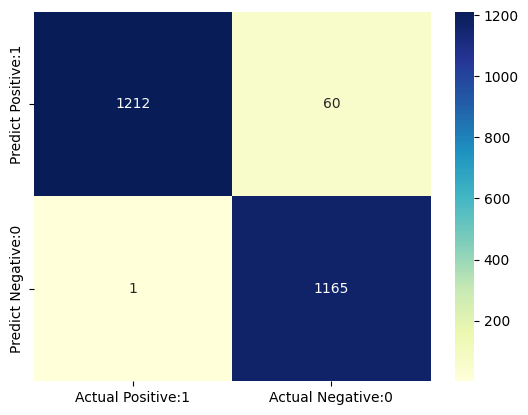

In [69]:
cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'],
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

In [70]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           e       1.00      0.95      0.98      1272
           p       0.95      1.00      0.97      1166

    accuracy                           0.97      2438
   macro avg       0.98      0.98      0.97      2438
weighted avg       0.98      0.97      0.97      2438



In [72]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(gnb, X_train, y_train, cv = 10, scoring='accuracy')

print('Cross-validation scores:{}'.format(scores))

Cross-validation scores:[0.97188049 0.9771529  0.97012302 0.96660808 0.98066784 0.98066784
 0.97183099 0.97359155 0.97887324 0.97535211]


In [73]:
print('Average cross-validation score: {:.4f}'.format(scores.mean()))

Average cross-validation score: 0.9747


In [74]:
from sklearn.naive_bayes import BernoulliNB


bnb = BernoulliNB()
bnb.fit(X_train, y_train)


y_pred_bnb = bnb.predict(X_test)


print('BernoulliNB accuracy: {0:0.4f}'.format(accuracy_score(y_test, y_pred_bnb)))


scores_bnb = cross_val_score(bnb, X_train, y_train, cv=10, scoring='accuracy')
print('Cross-validation score: {0:0.4f}'.format(scores_bnb.mean()))

print(classification_report(y_test, y_pred_bnb))

BernoulliNB accuracy: 0.9467
Cross-validation score: 0.9355
              precision    recall  f1-score   support

           e       0.92      0.99      0.95      1272
           p       0.99      0.90      0.94      1166

    accuracy                           0.95      2438
   macro avg       0.95      0.94      0.95      2438
weighted avg       0.95      0.95      0.95      2438



In [75]:
from sklearn.tree import DecisionTreeClassifier


dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)


y_pred_dt = dt.predict(X_test)


print('Decision Tree accuracy: {0:0.4f}'.format(accuracy_score(y_test, y_pred_dt)))


scores_dt = cross_val_score(dt, X_train, y_train, cv=10, scoring='accuracy')
print('Cross-validation score: {0:0.4f}'.format(scores_dt.mean()))


print(classification_report(y_test, y_pred_dt))

Decision Tree accuracy: 1.0000
Cross-validation score: 0.9998
              precision    recall  f1-score   support

           e       1.00      1.00      1.00      1272
           p       1.00      1.00      1.00      1166

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



In [76]:
print('Training set score: {:.4f}'.format(dt.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(dt.score(X_test, y_test)))

Training set score: 1.0000
Test set score: 1.0000


In [77]:
from sklearn.neighbors import KNeighborsClassifier


knn = KNeighborsClassifier()
knn.fit(X_train, y_train)


y_pred_knn = knn.predict(X_test)


print('KNN accuracy: {0:0.4f}'.format(accuracy_score(y_test, y_pred_knn)))


scores_knn = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
print('Cross-validation score: {0:0.4f}'.format(scores_knn.mean()))


print(classification_report(y_test, y_pred_knn))

KNN accuracy: 1.0000
Cross-validation score: 1.0000
              precision    recall  f1-score   support

           e       1.00      1.00      1.00      1272
           p       1.00      1.00      1.00      1166

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



In [79]:
import pickle


pickle.dump(gnb, open('gnb_model.pkl', 'wb'))
pickle.dump(bnb, open('bnb_model.pkl', 'wb'))
pickle.dump(dt, open('dt_model.pkl', 'wb'))
pickle.dump(knn, open('knn_model.pkl', 'wb'))

In [82]:
from google.colab import files

files.download('gnb_model.pkl')
files.download('bnb_model.pkl')
files.download('dt_model.pkl')
files.download('knn_model.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [81]:
import pickle
from google.colab import files

# حفظ الـ columns
pickle.dump(X_train.columns.tolist(), open('columns.pkl', 'wb'))

# نزليه
files.download('columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>